# MCMC analysis of FRB constraints on cosmological parameters and cosmic baryons

In [1]:
### If the MCMC functions need to be imported from a file, this should be OFF
## Depends on how the OS handles multiprossecing
RUN_IN_NOTEBOOK = False

In [2]:
import sys
sys.path.append('../../Python_scripts')
sys.path.append('../interpolation')

## Import packages
from config import *
from support import *
from mcmc_support import *
from cosmo_support import *

In [3]:
# import emcee
# from multiprocessing import Pool

## Upload data

In [4]:
data=pd.read_csv('../../Data/FRB.csv')
data

,FRB,z,DM,DM_ext,From
0,FRB 20180814A,0.06800,190.900,73.30,Fan
1,FRB 20181030A,0.00385,103.396,32.30,Fan
2,FRB 20220529A,0.18390,246.000,176.00,Fan
3,FRB 20220610A,1.01600,1458.150,1397.15,Fan
4,FRB 20220717A,0.36295,637.340,489.04,Fan
...,...,...,...,...,...
112,FRB 20231204A,0.06440,221.000,159.94,CHIME2025
113,FRB 20231206A,0.06590,457.700,370.12,CHIME2025
114,FRB 20231223C,0.10590,165.800,87.07,CHIME2025
115,FRB 20231229A,0.01900,198.500,110.98,CHIME2025


In [5]:
print(len(data))
data = data[data['FRB'] != 'FRB 20190520B']
data = data[data['FRB'] != 'FRB 20220831A']
data03 = data[data['z'] >= 0.3]
# data = data[data['z'] >= 0.1]
print(len(data03))
data03.head()

117
36


,FRB,z,DM,DM_ext,From
3,FRB 20220610A,1.01600,1458.15,1397.15,Fan
4,FRB 20220717A,0.36295,637.34,489.04,Fan
6,FRB 20230521B,1.35400,1342.90,1174.10,Fan
7,FRB 20230814A,0.55300,696.40,561.60,Fan
8,FRB 20231220A,0.33550,491.20,411.30,Fan


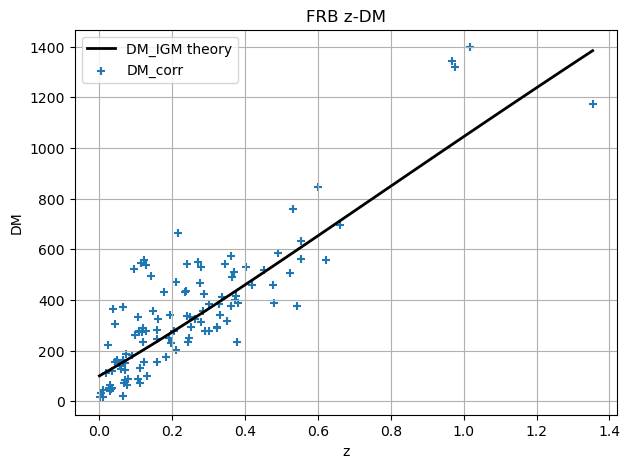

In [6]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0, np.max(data['z']), 100)

DM_theory = np.zeros_like(z_range)
for idx, redshift in enumerate(z_range):
    DM_theory[idx] = dispersion_measure(redshift, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)

ax1.plot(z_range, 100+DM_theory, lw=2, c='black', label='DM_IGM theory')
ax1.scatter(data['z'], data['DM_ext'], s=40, marker='+', label='DM_corr')  
ax1.set_xlabel('z')
ax1.set_ylabel('DM')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

# Preparation interpolation

In [7]:
if RUN_IN_NOTEBOOK:

    load_arrays=np.load('./interpolation/A_C0_Macquart.npz')
    Sigmas=load_arrays['a']
    C0s=load_arrays['c']
    As=load_arrays['b']

In [8]:
C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [9]:
A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

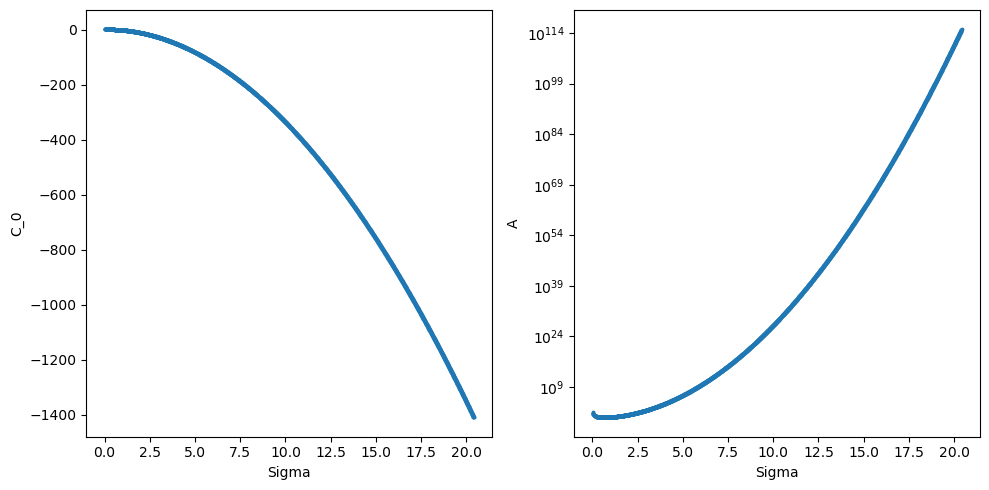

In [8]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.scatter(Sigmas, C0s,  s=3)
ax1.set_ylabel('C_0')
ax1.set_xlabel('Sigma')

ax2.scatter(Sigmas, As,  s=3)
ax2.set_ylabel('A')
ax2.set_xlabel('Sigma')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

# MCMC

Constrain $H_0 \Omega_0 f_{IGM}=const $

In [9]:
if RUN_IN_NOTEBOOK:
    
    def calculate_dm_probability_num_HOf_fast1(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
        ## Cosmic calculation    
        DM_th = DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)

        Delta_array = np.linspace(0, DM_frb_max / DM_th, 5000)

        # sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
        sigma=f_sqrtvar_delta(F,z)

        C_0=C0_sigma_inter(sigma)#C0_sigma(sigma,condition='mean')#C0_sigma_inter(sigma)
        A = A_sigma_inter(sigma)#find_A_sigma(C_0=C_0, sigma=sigma) # A_sigma_inter(sigma)

        pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)

        ## Host calculation
        pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)

        ## Combine together    
        prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)

        ## Transform to probabilities
        # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)

        return prob*(1+z)
    
    
    def sigma_error(error):
        return error
    
    

    def log_likelihood(theta, data):
        """
        Calculate the log likelihood for a set of parameters given the data.

        Args:
            theta: Array of parameters [F, HOf, sigma_host, e_mu]
            data: Pandas DataFrame containing FRB data

        Returns:
            Log likelihood
        """
        F, HOf, sigma_host, e_mu = theta

        log_like = 0.0

        try:
            for _, row in data.iterrows():
                prob = calculate_dm_probability_num_HOf_fast(
                    DM_frb_max=row['DM_ext'],
                    z=row['z'],
                    S=F,
                    HOf=HOf,
                    sigma_host=sigma_host,
                    e_mu=e_mu,
                    f_sigma_error=sigma_error,f_C0_sigma=C0_sigma_inter,f_A_sigma=A_sigma_inter,error_calculator=f_sqrtvar_delta
                )

                if prob > 0:
                    log_like += np.log(prob)
                else:
                    return -np.inf

            return log_like
        except Exception as e:
            print(f"Error in log_likelihood: {e} with parameters {theta}")
            return -np.inf
        
        
    def log_prior(theta):
        """
        Calculate the log of the prior probability for a set of parameters.

        Args:
            theta: Array of parameters [F, HOf, sigma_host, e_mu]

        Returns:
            Log prior probability
        """
        F, HOf, sigma_host, e_mu = theta

        # Define your prior ranges here
        F_min, F_max = 0.01, 1.0 # Example range, adjust based on your model
        HOf_min, HOf_max = 1.0, 5.0  # Example range, adjust based on your model
        sigma_host_min, sigma_host_max = 0.2,1.4  # Example range
        e_mu_min, e_mu_max = 10, 250  # Example range # e_mu_min, e_mu_max = 50, 300  # Example range

        # Check if parameters are within prior ranges
        if (F_min <= F <= F_max and 
            HOf_min <= HOf <= HOf_max and 
            sigma_host_min <= sigma_host <= sigma_host_max and 
            e_mu_min <= e_mu <= e_mu_max):
            return 0.0  # Log(1) = 0, flat prior
        else:
            return -np.inf  # Log(0) = -inf, outside prior range        

    def log_probability(theta, data):
        """
        Calculate the log probability (posterior) for a set of parameters.

        Args:
            theta: Array of parameters [F, HOf, sigma_host, e_mu]
            data: Pandas DataFrame containing FRB data

        Returns:
            Log posterior probability
        """
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf

        ll = log_likelihood(theta, data)
        if not np.isfinite(ll):
            return -np.inf

        return lp + ll

    def run_mcmc(data, initial_params, nwalkers=32, heating=10, nsteps=10000, ndim=4):
        """
        Run the MCMC analysis.

        Args:
            data: Pandas DataFrame containing FRB data
            initial_params: Initial parameter values [F, HOf, sigma_host, e_mu]
            nwalkers: Number of walkers
            nsteps: Number of steps per walker
            ndim: Number of dimensions (parameters)

        Returns:
            sampler: emcee sampler object with results
        """
        # Set initial positions with small random offsets
        pos = initial_params + 0.1 * np.random.randn(nwalkers, ndim)
        # pos = [initial_params + _*1e-2 * np.random.randn(ndim) for _ in range(nwalkers)]

        for i in range(nwalkers):
            while log_prior(pos[i]) == -np.inf:
                pos[i] = initial_params + 0.1 * np.random.randn(ndim)

        # Set up the sampler
        with Pool() as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, log_probability, 
                args=(data,), pool=pool,
                moves=[(emcee.moves.DEMove(), 0.8),
                       (emcee.moves.DESnookerMove(), 0.2)]
            )

            # Run the MCMC
            print("Running MCMC...")

            print("heating...")
            state = None
            with tqdm(total=heating) as pbar:
                for i, result in enumerate(sampler.sample(pos, iterations=heating)):
                    pbar.update(1)
                    state = result
                    if i % 100 == 0:
                        # Calculate acceptance fraction periodically
                        acc_frac = np.mean(sampler.acceptance_fraction)
                        pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")

            print("main running...")
            with tqdm(total=nsteps) as pbar:
                for i, result in enumerate(sampler.sample(state.coords, iterations=nsteps)):
                    pbar.update(1)

                    # check acceptance fraction
                    if i % 100 == 0:
                        acc_frac = np.mean(sampler.acceptance_fraction)
                        pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")

                        # if acceptance fraction always = 0，reset initial parameters
                        if i > 500 and acc_frac < 0.001:
                            print("warning: acceptance fraction too low，reset parameters or resun MCMC")

        # check acceptance fraction
        final_acc_frac = np.mean(sampler.acceptance_fraction)
        print(f"final acceptance fraction: {final_acc_frac:.3f}")

        if final_acc_frac < 0.01:
            print("warning: acceptance fraction too low，reset parameters or resun MCMC")

        return sampler

In [10]:
DM_frb_max=1174.1
z=1.354
S=0.05
HOf=2.8
e_mu=100
sigma_host=0.75

print(calculate_dm_probability_num_HOf_fast1(DM_frb_max, z, S, HOf, e_mu, sigma_host))
print(calculate_dm_probability_num_HOf_fast(DM_frb_max, z, S, HOf, e_mu, sigma_host, f_sigma_error=sigma_error,f_C0_sigma=C0_sigma_inter,f_A_sigma=A_sigma_inter,error_calculator=f_sqrtvar_delta))
print(calculate_dm_probability_num_HOf_fast(DM_frb_max, z, S, HOf, e_mu, sigma_host, f_sigma_error=sigma_error,f_C0_sigma=C0_sigma_inter,f_A_sigma=A_sigma_inter,error_calculator=f_sqrtvar_delta,space='DM'))

0.00024647884761815194
0.00024647884761815194
0.000246478847618152


In [ ]:
# Main execution
if __name__ == "__main__":
    
    # Define initial parameters: [F, HOf, sigma_host, e_mu]
    initial_params = np.array([0.1, 3.0, 0.8, 150])  # Adjust based on your model
    
    # Run MCMC
    sampler03 = run_mcmc(data03, initial_params, nwalkers=32, heating=100,nsteps=20000)

Running MCMC...
heating...


Acceptance fraction: 0.500: 100%|██████████| 100/100 [00:04<00:00, 22.14it/s]


main running...


Acceptance fraction: 0.190: 100%|██████████| 20000/20000 [11:45<00:00, 28.35it/s] 


final acceptance fraction: 0.190


NameError: name 'analyze_results' is not defined

In [22]:
# Analyze results
samples03, params_median03, params_errors03 = mcmc_analyze_results(sampler03)
    
# Print results
param_names = ['F', 'HOf', 'sigma_host', 'e_mu']
print("\nMCMC Results:")
for i, name in enumerate(param_names):
    print(f"{name} = {params_median03[i]:.3f} ± {params_errors03[i]:.3f}")
    
# Plot results
# plot_results(samples, param_names)
    
# Save samples to file for later analysis if needed
np.save('./posterior/mcmc_Macquart_z03.npy', samples03)
    
print("\nMCMC analysis complete!")


MCMC Results:
F = 0.476 ± 0.240
HOf = 2.901 ± 0.337
sigma_host = 0.633 ± 0.290
e_mu = 90.645 ± 54.666

MCMC analysis complete!


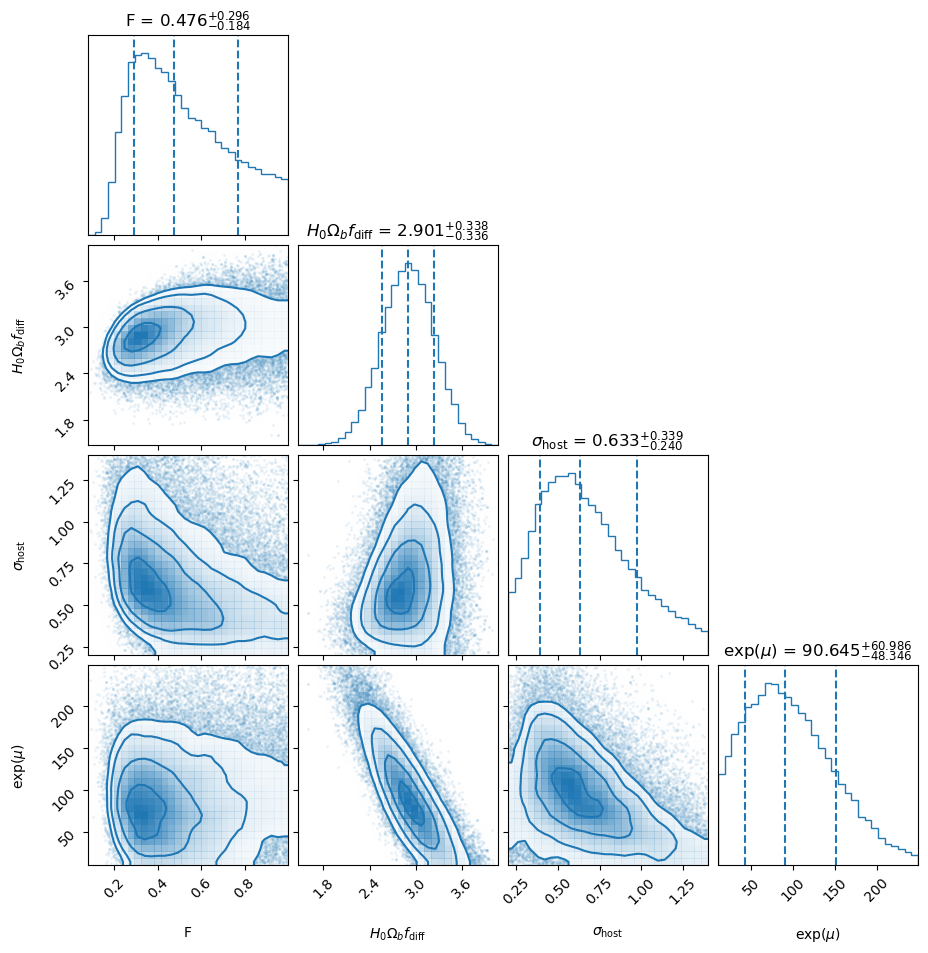

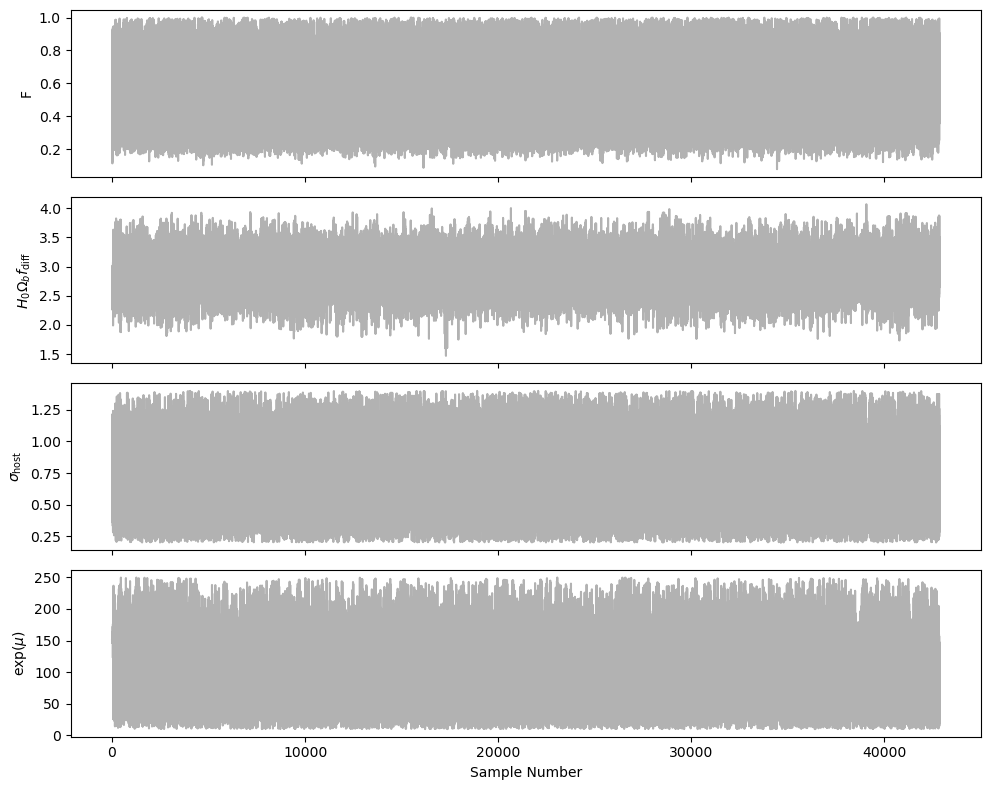

In [2]:
param_names = ['F', r'$H_0 \Omega_b f_{\rm diff}$', r'$\sigma_{\rm host}$', r'$\exp(\mu)$']
samples03=np.load('./posterior/mcmc_Macquart_z03.npy')
mcmc_plot_results(samples03, param_names,savetitle='./plot/MCMC_Macquart_z03')

In [ ]:
HOf_fiducial=68*OMEGA_BARYONS*0.82
print(HOf_fiducial)

2.7305672


For Macquart method without low redshift drop

In [22]:
print(len(data))

115


In [15]:
# Main execution
if __name__ == "__main__":
    
    # Define initial parameters: [F, HOf, sigma_host, e_mu]
    initial_params = np.array([0.1, 3.0, 0.8, 150])  # Adjust based on your model
    
    # Run MCMC
    sampler = run_mcmc(data, initial_params, nwalkers=8, heating=10,nsteps=2000)
    
    # Analyze results
    samples, params_median, params_errors = mcmc_analyze_results(sampler)
    
    # Print results
    param_names = ['F', 'HOf', 'sigma_host', 'e_mu']
    print("\nMCMC Results:")
    for i, name in enumerate(param_names):
        print(f"{name} = {params_median[i]:.3f} ± {params_errors[i]:.3f}")
    
    # Plot results
    # plot_results(samples, param_names)
    
    # Save samples to file for later analysis if needed
    # np.save('./posterior/mcmc_Macquart.npy', samples)
    
    print("\nMCMC analysis complete!")

Running MCMC...
heating...


Acceptance fraction: 0.250: 100%|██████████████████████████████████████████████████████| 10/10 [00:10<00:00,  1.05s/it]


main running...


Acceptance fraction: 0.213: 100%|██████████████████████████████████████████████████| 2000/2000 [12:49<00:00,  2.60it/s]

final acceptance fraction: 0.213

MCMC Results:
F = 0.521 ± 0.056
HOf = 2.484 ± 0.168
sigma_host = 1.126 ± 0.112
e_mu = 86.401 ± 18.111

MCMC analysis complete!


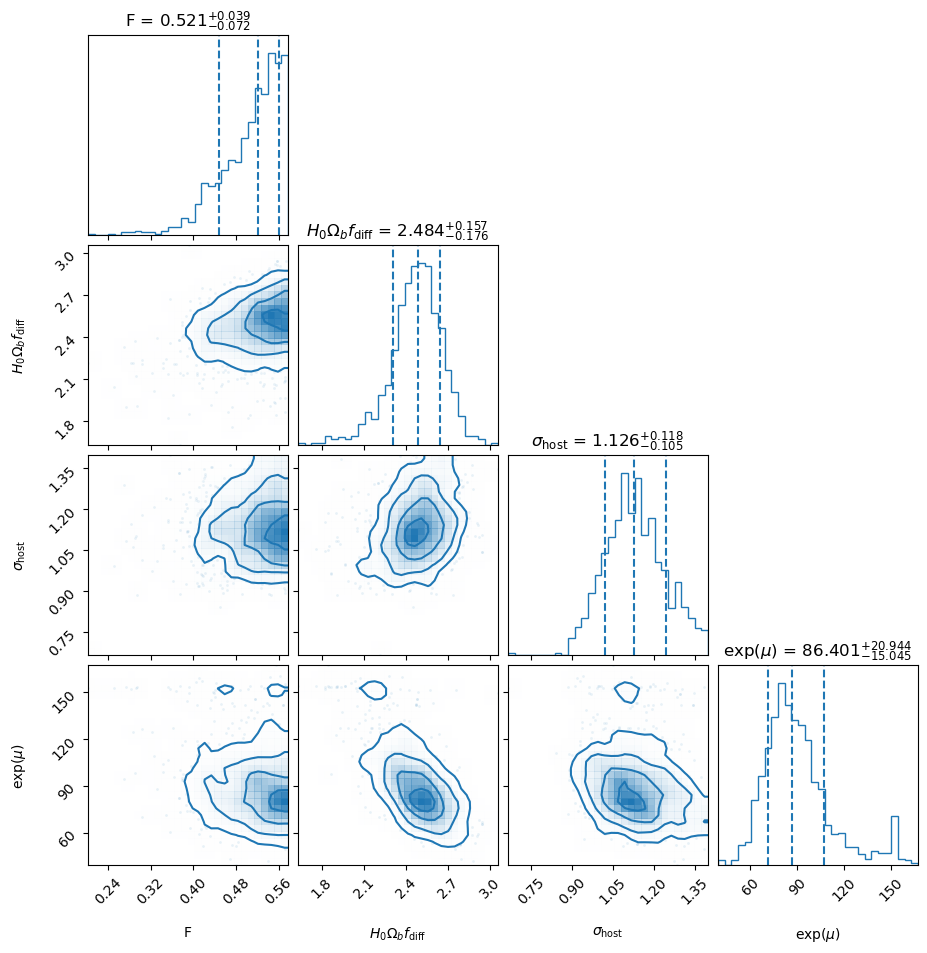

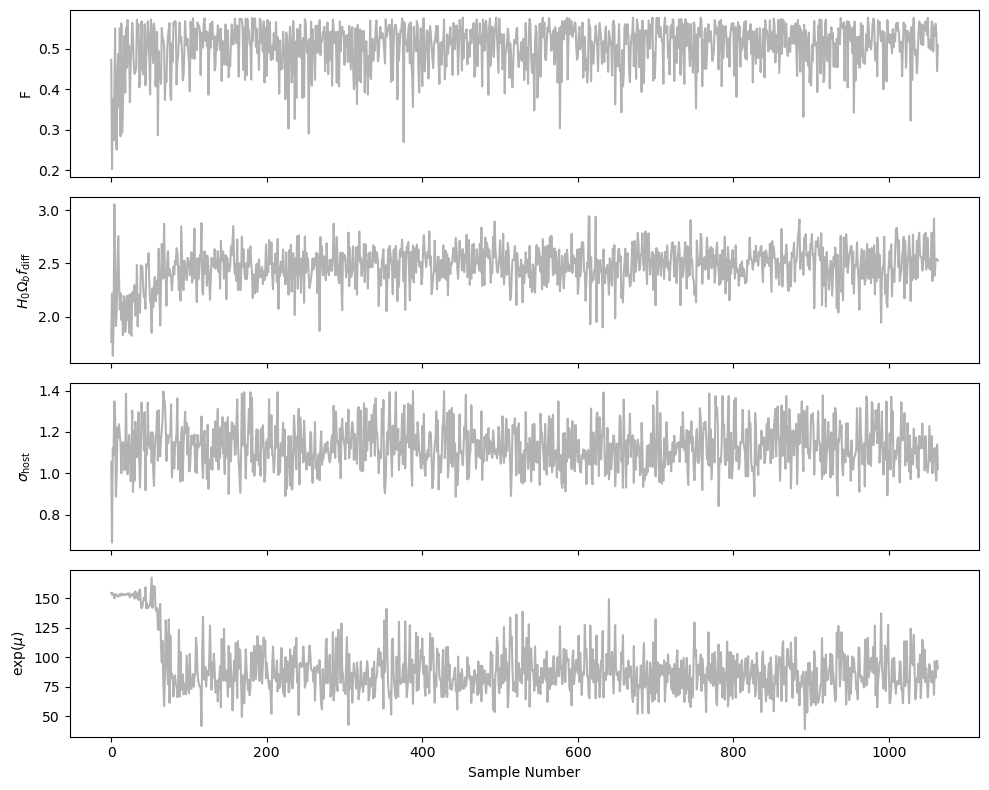

In [16]:
param_names = ['F', r'$H_0 \Omega_b f_{\rm diff}$', r'$\sigma_{\rm host}$', r'$\exp(\mu)$']
# samples=np.load('./posterior/mcmc_Macquart.npy')
mcmc_plot_results(samples, param_names) #,savetitle='./plot/MCMC_Macquart')